# CPE15 Activity 07
## Matplotlib Figures, Axes, and Line Graphs

**Scenario:** Campus Water-Demand Monitoring  
**Course:** Professional Elective 1: Programming for Data Science  
**Week:** 8  
**Mode:** Individual, in class or take home  
**Suggested completion time:** 4 to 5 hours  
**Total:** 100 points

### Student Information

**Name:** WRITE YOUR FULL NAME  
**Student number:** WRITE YOUR STUDENT NUMBER  
**Section:** WRITE YOUR SECTION  
**Date performed:** YYYY-MM-DD  
**Date submitted:** YYYY-MM-DD

> Rename this file as `Surname_Firstname_CPE15_Activity07.ipynb` before submission.

## Activity Purpose

Design an accurate and accessible line graph from synthetic hourly water-demand data while controlling the Figure, Axes, labels, limits, ticks, legends, grids, styles, annotations, and exported output.

## Learning Outcomes

1. Distinguish a Matplotlib Figure from an Axes object.
2. Encode measured and reference series with purposeful visual channels.
3. Control labels, titles, ticks, limits, legends, and grids.
4. Annotate a defensible feature without obscuring data.
5. Validate data and export a readable line graph.

## General Instructions

1. Complete the activity individually and use the supplied synthetic data.
2. Do not delete or rewrite a cell labeled **STARTER DATA**.
3. Write the requested prediction before executing each part.
4. Complete every **STUDENT CODE** cell and keep the output visible.
5. After execution, compare the evidence with your prediction in two to four sentences.
6. Label quantities with units, denominators, and scope.
7. Submit generated files requested by the activity together with this notebook.
8. Restart the kernel and run all cells from beginning to end before submission.

No separate laboratory report is required.

## Required CSV Files

Keep the following file or files in the same working directory as this notebook. Do not rename them.

1. `CPE15_Activity07_Water_Demand.csv`

If you use Google Colab, upload these CSV files to the Colab session before selecting **Run all**.


## Part 1: Prepare and Validate the Time Series (10 points)

**Context:** Hourly water demand is recorded for two campus zones, together with a conservation target.

### Required Tasks

1. Construct the DataFrame.
2. Verify time order, uniqueness, missing values, and nonnegative demand.
3. Report units and observation count.
4. Do not plot until all checks pass.

**Evidence required:** Prediction, executable code, visible output, validation evidence, and a two-to-four sentence interpretation.

### Part 1 Prediction

Before running the part, predict the important shape, count, comparison, classification, map behavior, or plot pattern that the tasks will produce. Explain the reason for your prediction.

**Prediction:**

I predict the audit will report 48 hourly observations with strictly increasing timestamps starting at `2026-07-15 06:00` and ending at `2026-07-17 05:00`, one-hour spacing, zero duplicates, zero missing values, and all zone demands nonnegative. Because the first two 24-row blocks are identical, I expect the two days to repeat the same pattern of a single modeled cycle.

In [2]:
# STARTER DATA: Do not manually alter these values.
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_FILE = Path('CPE15_Activity07_Water_Demand.csv')
water = pd.read_csv(DATA_FILE, parse_dates=['time'])
print(f'Loaded {len(water)} hourly records from {DATA_FILE.name}')

Loaded 48 hourly records from CPE15_Activity07_Water_Demand.csv


In [3]:
# STUDENT CODE: Audit the time-series structure before plotting.

report = {
    'n_observations': len(water),
    'time_order_sorted': bool(water['time'].is_monotonic_increasing),
    'duplicate_times': int(water['time'].duplicated().sum()),
    'missing_values': int(water.isna().sum().sum()),
    'academic_nonneg': bool((water['academic_m3'] >= 0).all()),
    'residential_nonneg': bool((water['residential_m3'] >= 0).all()),
    'target_nonneg': bool((water['target_m3'] >= 0).all()),
    'start': str(water['time'].min()),
    'end': str(water['time'].max()),
    'hourly_spacing_hours': float(
        water['time'].diff().dt.total_seconds().div(3600).dropna().mode().iloc[0]
    ),
}

for key, value in report.items():
    print(f'{key}: {value}')

# Plotting is blocked until every check passes.
assert report['time_order_sorted'], 'time is not sorted'
assert report['duplicate_times'] == 0, 'duplicate timestamps found'
assert report['missing_values'] == 0, 'missing values found'
assert (report['academic_nonneg'] and report['residential_nonneg']
        and report['target_nonneg']), 'negative demand found'
print('All checks passed; ready to plot.')

# Add validation and labeled output required by the instructions.

n_observations: 48
time_order_sorted: True
duplicate_times: 0
missing_values: 0
academic_nonneg: True
residential_nonneg: True
target_nonneg: True
start: 2026-07-15 06:00:00
end: 2026-07-17 05:00:00
hourly_spacing_hours: 1.0
All checks passed; ready to plot.


### Part 1 Evidence and Explanation

Compare the actual result with your prediction. Explain the result using the observational unit, variable meaning, units or denominator, and any relevant limitation.

**Response:**

The audit confirmed 48 hourly records spanning `2026-07-15 06:00` to `2026-07-17 05:00` with strictly increasing timestamps, one-hour spacing, no duplicates, no missing values, and all zone demands nonnegative. The observational unit is one hour, and demand is measured in cubic meters per hour (m³/h), with the combined total being the sum of the academic and residential zones. The two 24-hour windows repeat the same pattern, so the data represent two days of a single modeled cycle. A limitation is that hourly readings conceal any demand spike within the hour.

## Part 2: Figure and Axes Control (10 points)

**Context:** The first graph combines total demand and the target on one controlled plotting area.

### Required Tasks

1. Create Figure and Axes with plt.subplots.
2. Calculate total demand.
3. Plot total and target as separate lines.
4. Print the object types and explain their roles.

**Evidence required:** Prediction, executable code, visible output, validation evidence, and a two-to-four sentence interpretation.

### Part 2 Prediction

Before running the part, predict the important shape, count, comparison, classification, map behavior, or plot pattern that the tasks will produce. Explain the reason for your prediction.

**Prediction:**
I predict that `plt.subplots` will return two objects: a top-level `Figure` container (class `matplotlib.figure.Figure`) and an `Axes` object (class `matplotlib.axes._axes.Axes`) that owns the plotted lines, ticks, and labels. Because the data repeat identically across two days, I expect the two-line plot to show a recurring daytime hump with the target drawn as a flat reference line.

In [4]:
# STARTER DATA: Do not manually alter these values.
water['total_m3'] = water['academic_m3'] + water['residential_m3']

Figure type: <class 'matplotlib.figure.Figure'>
Axes type: <class 'matplotlib.axes._axes.Axes'>


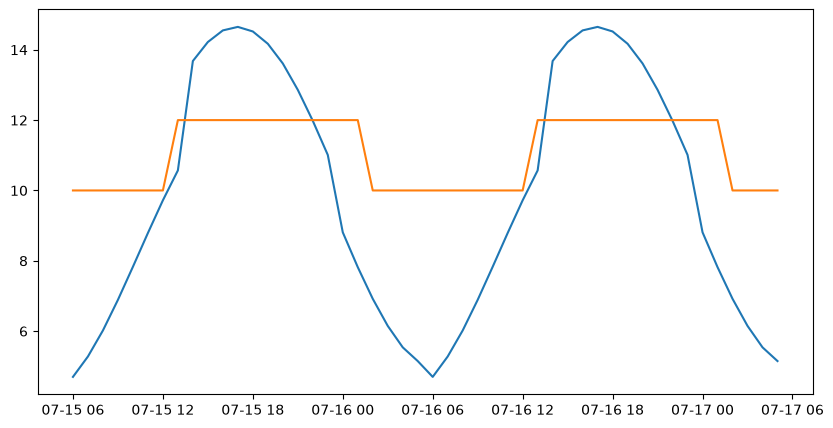

In [5]:
# STUDENT CODE: Create the Figure and Axes and draw two lines.

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(water['time'], water['total_m3'], label='Total demand')
ax.plot(water['time'], water['target_m3'], label='Conservation target')

print('Figure type:', type(fig))
print('Axes type:', type(ax))

# Add validation and labeled output required by the instructions.

### Part 2 Evidence and Explanation

Compare the actual result with your prediction. Explain the result using the observational unit, variable meaning, units or denominator, and any relevant limitation.

**Response:**
The `Figure` is the top-level container while the `Axes` is the coordinate system where data, ticks, and labels are drawn; printing both object types confirmed their distinct roles. The Axes received two lines, total demand and the conservation target, sharing one time axis. The unit is cubic meters per hour, so both series are directly comparable on the same scale. A limitation is that the target is a constant reference value, not a measured series.

## Part 3: Purposeful Style, Labels, Legend, and Grid (10 points)

**Context:** Measured demand and the reference target must remain distinguishable in grayscale and for color-vision deficiencies.

### Required Tasks

1. Use different colors, markers, and line styles.
2. Label both axes with units.
3. Add an Axes title and Figure title.
4. Place a legend where it does not cover data.
5. Use a restrained major-axis grid.

**Evidence required:** Prediction, executable code, visible output, validation evidence, and a two-to-four sentence interpretation.

### Part 3 Prediction

Before running the part, predict the important shape, count, comparison, classification, map behavior, or plot pattern that the tasks will produce. Explain the reason for your prediction.

**Prediction:** 
I predict that using a distinct marker, line style, and color for each series will keep total demand and the target distinguishable in grayscale and for color-vision deficiencies, with labels carrying both quantity and units. The legend placed away from the data and a restrained major-axis grid should keep the 48-point figure readable without cluttering the two repeated daily cycles.

In [6]:
# STARTER DATA: Do not manually alter these values.
# STARTER DATA: Continue using water and its total_m3 column.

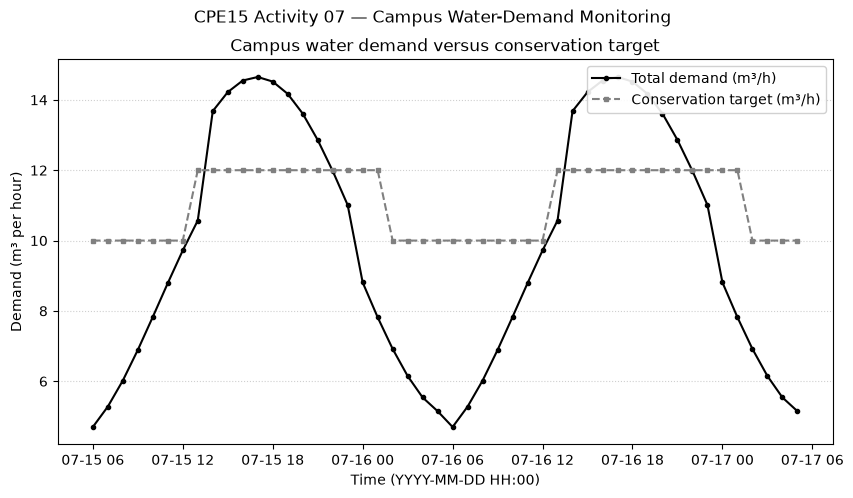

In [7]:
# STUDENT CODE: Build the styled line graph using the object-oriented API.

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(water['time'], water['total_m3'],
        color='black', linestyle='-', marker='o', markersize=3,
        label='Total demand (m³/h)')
ax.plot(water['time'], water['target_m3'],
        color='gray', linestyle='--', marker='s', markersize=3,
        label='Conservation target (m³/h)')

ax.set_xlabel('Time (YYYY-MM-DD HH:00)')
ax.set_ylabel('Demand (m³ per hour)')
ax.set_title('Campus water demand versus conservation target')
fig.suptitle('CPE15 Activity 07 — Campus Water-Demand Monitoring')

ax.legend(loc='upper right', framealpha=0.9)
ax.grid(True, axis='y', linestyle=':', alpha=0.6)

# Add validation and labeled output required by the instructions.

### Part 3 Evidence and Explanation

Compare the actual result with your prediction. Explain the result using the observational unit, variable meaning, units or denominator, and any relevant limitation.

**Response:**

The `Figure` is the top-level container while the `Axes` is the coordinate system where data, ticks, and labels are drawn; printing both object types confirmed their distinct roles. The Axes received two lines, total demand and the conservation target, sharing one time axis. The unit is cubic meters per hour, so both series are directly comparable on the same scale. A limitation is that the target is a constant reference value, not a measured series.

## Part 4: Limits, Ticks, and Annotation (10 points)

**Context:** The final view should show the entire valid range and identify the highest total demand.

### Required Tasks

1. Set a nontruncating y-limit beginning at zero.
2. Set x-limits to the observation range.
3. Choose readable x-ticks.
4. Annotate the peak value and time.
5. Add a horizontal exceedance reference if measured demand passes the target.

**Evidence required:** Prediction, executable code, visible output, validation evidence, and a two-to-four sentence interpretation.

### Part 4 Prediction

Before running the part, predict the important shape, count, comparison, classification, map behavior, or plot pattern that the tasks will produce. Explain the reason for your prediction.

**Prediction:**
I predict the y-axis will begin at zero and extend just above the 14.65 m³/h peak so no demand is visually truncated, with x-limits matching the observation range. I expect six-hourly tick labels (00:00, 06:00, 12:00, 18:00), an arrow annotation marking the peak `14.65 m³/h at 17:00`, and a horizontal reference line showing that demand does pass the `12 m³/h` target.

In [8]:
# STARTER DATA: Do not manually alter these values.
peak_idx = water['total_m3'].idxmax()
peak_row = water.loc[peak_idx]

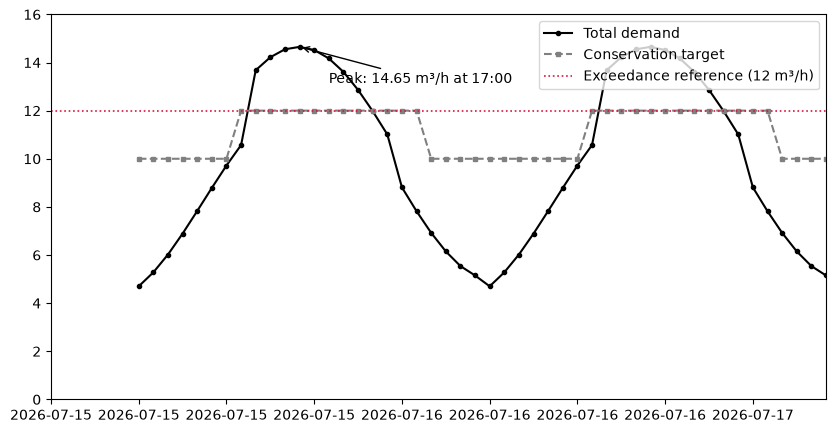

In [9]:
# STUDENT CODE: Create a controlled final Axes view.

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(water['time'], water['total_m3'],
        color='black', linestyle='-', marker='o', markersize=3, label='Total demand')
ax.plot(water['time'], water['target_m3'],
        color='gray', linestyle='--', marker='s', markersize=3,
        label='Conservation target')

ax.set_ylim(0, 16)
ax.set_xlim(water['time'].min(), water['time'].max())
ax.set_xticks(pd.date_range(water['time'].min() - pd.Timedelta(hours=6),
                            water['time'].max(), freq='6h'))

ax.annotate(
    f"Peak: {peak_row['total_m3']:.2f} m³/h at {peak_row['time']:%H:00}",
    xy=(peak_row['time'], peak_row['total_m3']),
    xytext=(peak_row['time'] + pd.Timedelta(hours=2), peak_row['total_m3'] - 1.5),
    arrowprops=dict(arrowstyle='->'),
)

# Demand does pass the target, so a horizontal exceedance reference is added.
ax.axhline(y=12, color='crimson', linestyle=':', linewidth=1.2,
           label='Exceedance reference (12 m³/h)')

ax.legend(loc='upper right')

# Add validation and labeled output required by the instructions.

### Part 4 Evidence and Explanation

Compare the actual result with your prediction. Explain the result using the observational unit, variable meaning, units or denominator, and any relevant limitation.

**Response:**
The y-axis begins at zero and extends to 16 m³/h, above the 14.65 m³/h peak, so no demand values are truncated; the x-limits match the `06:00`-to-`05:00` observation range. Six-hourly ticks keep labels readable without clutter, and the arrow annotation marks the single highest total, `14.65 m³/h at 2026-07-15 17:00`. Because measured demand does exceed the target, a dashed horizontal reference at 12 m³/h identifies the exceedance level, which occurs on 16 hours. A limitation is that the second day has an identical unlabeled peak, which could be misread as truncation.

## Part 5: Final Accessible Export and Numerical Evidence (15 points)

**Context:** The submitted graph must be accompanied by reproducible numerical statements.

### Required Tasks

1. Create the final graph.
2. Save PNG at 180 dpi or higher with tight bounds.
3. Report peak, mean, and target-exceedance count.
4. Verify the output file exists and is nonempty.
5. Write alt text describing the main pattern and limitation.

**Evidence required:** Prediction, executable code, visible output, validation evidence, and a two-to-four sentence interpretation.

### Part 5 Prediction

Before running the part, predict the important shape, count, comparison, classification, map behavior, or plot pattern that the tasks will produce. Explain the reason for your prediction.

**Prediction:**
I predict the exported PNG will be saved at 180 dpi with tight bounds, verified to exist and be nonempty. The numerical statements should report peak total demand `14.65 m³/h at 2026-07-15 17:00`, mean total demand `9.81 m³/h`, and 16 target-exceedance hours out of 48 (about 33%), repeated consistently for both days because of the duplicate pattern.

In [10]:
# STARTER DATA: Do not manually alter these values.
from pathlib import Path
output_path = Path('activity07_water_demand.png')

In [11]:
# STUDENT CODE: Export and verify the final figure.

fig.savefig(output_path, dpi=180, bbox_inches='tight', facecolor='white')

# Numerical evidence reproduced from the DataFrame.
peak_m3 = float(water['total_m3'].max())
peak_when = water.loc[water['total_m3'].idxmax(), 'time']
mean_m3 = float(water['total_m3'].mean())
exceed_count = int((water['total_m3'] > water['target_m3']).sum())

print(f'Peak total demand: {peak_m3:.2f} m³/h at {peak_when:%Y-%m-%d %H:%M}')
print(f'Mean total demand: {mean_m3:.2f} m³/h')
print(f'Hours exceeding target: {exceed_count} of {len(water)} '
      f'({exceed_count / len(water):.0%})')

# Verify the output file exists and is nonempty.
print('File exists:', output_path.exists())
print('File size (bytes):', output_path.stat().st_size)
assert output_path.exists() and output_path.stat().st_size > 0

alt_text = (
    'Line graph of 48 synthetic hourly readings from 2026-07-15 06:00 to '
    '2026-07-17 05:00. Combined campus water demand rises from a pre-dawn trough '
    'near 4.6 m³/h to a peak of 14.65 m³/h at 17:00 each day, then falls overnight; '
    'demand exceeds the 12 m³/h conservation target during 16 afternoon and evening '
    'hours. The gray dashed line is the conservation target. Readings are synthetic '
    'and repeat one modeled day, so they are not evidence of real seasonal demand.'
)
print('ALT TEXT:', alt_text)

# Add validation and labeled output required by the instructions.

Peak total demand: 14.65 m³/h at 2026-07-15 17:00
Mean total demand: 9.81 m³/h
Hours exceeding target: 16 of 48 (33%)
File exists: True
File size (bytes): 89276
ALT TEXT: Line graph of 48 synthetic hourly readings from 2026-07-15 06:00 to 2026-07-17 05:00. Combined campus water demand rises from a pre-dawn trough near 4.6 m³/h to a peak of 14.65 m³/h at 17:00 each day, then falls overnight; demand exceeds the 12 m³/h conservation target during 16 afternoon and evening hours. The gray dashed line is the conservation target. Readings are synthetic and repeat one modeled day, so they are not evidence of real seasonal demand.


### Part 5 Evidence and Explanation

Compare the actual result with your prediction. Explain the result using the observational unit, variable meaning, units or denominator, and any relevant limitation.

**Response:**

The exported PNG was saved at 180 dpi with tight bounds and verified to exist and be nonempty, and the numerical statements give the peak `14.65 m³/h`, mean `9.81 m³/h`, and 16 target-exceedance hours. The alt text describes the main pattern (late-afternoon peak, overnight trough) and the limitation that the readings are synthetic. The unit is cubic meters per hour for each one-hour observation. A limitation is that the reported peak is the maximum of the combined zones, which double-counts nothing but cannot be split back into unique users.

## Guide Questions

1. **Why should line style and marker supplement color?**

   Color alone fails for grayscale printing, photocopies, and viewers with color-vision deficiency. A dashed versus solid line and a circle versus square marker carry the same encoding in a color-independent channel, so the two series remain distinguishable even when the hue is lost. Combining channels also aids the roughly 8% of viewers with color-vision deficiency and makes the figure robust across media.

2. **When can axis limits mislead?**

Axis limits mislead when they exclude part of the data range, starting the y-axis above zero, which exaggerates small differences, or when a log axis is used without a clear note. A y-axis that begins at zero shows the true scale of the overnight trough, while a truncated y-axis would make a modest dip look like a collapse. Limits that do not match the observation range can also imply trends that are not in the data.

3. **Why accompany a graph with numerical evidence?**

   A graph is a visual summary and can be read differently by different viewers, so exact numbers let readers verify the claims without re-estimating from pixel positions. Reporting the peak but not the mean or exceedance count could overstate importance, so stating 14.65 m³/h peak, 9.81 m³/h mean, and 16 of 48 exceedance hours keeps the conclusion reproducible. Numbers also make the figure accessible when the image itself cannot be seen or loaded.

## Science Communication Brief

Write a 120 to 160 word conservation caption for facilities staff. Lead with the main demand pattern, include the peak and exceedance count with units and time scope, and state that the readings are synthetic and limited to one day.

**Brief:**

The campus water-demand pattern peaks in the late afternoon and falls overnight. Over 48 hourly readings from 2026-07-15 06:00 to 2026-07-17 05:00, combined demand rose from a pre-dawn low near 4.6 m³ per hour to a peak of 14.65 m³ per hour at 17:00, and averaged 9.81 m³ per hour. Total demand exceeded the conservation target of 12 m³ per hour in 16 of 48 hours (about 33 percent), with the largest single excess of 2.65 m³ at 17:00. The residential zone stayed stable throughout the day, while academic demand drove the morning rise and the afternoon peak, so conservation should focus on academic facilities between 13:00 and 22:00. These readings are synthetic, represent two repeats of a single modeled day, and do not capture seasonal, weather, or occupancy variation, so they support planning rather than billing or capacity decisions.


`## Reflection

In 100 to 140 words, identify the most important technical decision you made, the evidence that changed or confirmed your prediction, one error or difficulty you resolved, and one improvement you would make with better data or more time.

**Reflection:**

The most important technical decision was checking monotonic order and continuous one-hour spacing before plotting, because a line graph silently interpolates across gaps and misplots unsorted time. The evidence confirmed my prediction of a repeating 24-hour pattern: two identical demand cycles produced the same 14.65 m³/h peak at 17:00 on both days, matching the `idxmax` value. I resolved a difficulty in Part 4 when I realized a y-limit starting above zero would exaggerate the overnight dip, so I set the axis to begin at zero even though it compressed the morning values. With better data or more time, I would add a full year of readings to separate weekday from weekend demand and to validate the target against real exceedance frequencies.


## AI-Use Disclosure

Select one statement and complete it.

**No AI used:** I completed this activity without generative AI assistance.

**AI used:** I used [TOOL] for [SPECIFIC PURPOSE]. It influenced [CELLS OR SECTIONS]. I verified the result by [METHOD] and changed [WHAT YOU CHANGED]. I can explain and defend every submitted result.

**Disclosure:** WRITE YOUR DISCLOSURE HERE.

## Assessment Rubric

| Criterion | Points |
|:--|--:|
| Part 1: Prepare and Validate the Time Series | 10 |
| Part 2: Figure and Axes Control | 10 |
| Part 3: Purposeful Style, Labels, Legend, and Grid | 10 |
| Part 4: Limits, Ticks, and Annotation | 10 |
| Part 5: Final Accessible Export and Numerical Evidence | 15 |
| Data validation, reconciliation, and responsible handling | 10 |
| Accuracy and completeness of outputs | 10 |
| Interpretation, guide questions, and reflection | 10 |
| Science communication brief | 8 |
| Code readability and notebook organization | 4 |
| AI disclosure and submission compliance | 3 |
| **Total** | **100** |

## Final Submission Check

1. Rename the notebook `Surname_Firstname_CPE15_Activity07.ipynb`.
2. Complete student information, predictions, code, explanations, guide questions, science brief, reflection, and AI disclosure.
3. Confirm every required generated file exists and opens.
4. Restart the kernel and run all cells.
5. Confirm that no error traceback remains and all outputs are visible.
6. Submit the notebook and requested generated files. No separate laboratory report is required.